In [9]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
import sys,os
sys.path.append(os.path.abspath(".."))
from src.mashup_generator import generate_mashup
from src.feature_extraction import mel_spectrogram
TARGET_SR=44100

In [12]:
DATA_PATH = Path("../dataset/messy_mashup")
GENRE_PATH = DATA_PATH / "genres_stems"
NOISE_PATH = DATA_PATH / "ESC-50-master/audio"

### Selecting random genre and testing it

Selected genre: rock
..\dataset\messy_mashup\genres_stems\rock\rock.00005 ..\dataset\messy_mashup\genres_stems\rock\rock.00034 ..\dataset\messy_mashup\genres_stems\rock\rock.00054 ..\dataset\messy_mashup\genres_stems\rock\rock.00075
Audio length: 1323588
Duration (sec): 30.013333333333332
Amplitude range: -0.74529606 1.0


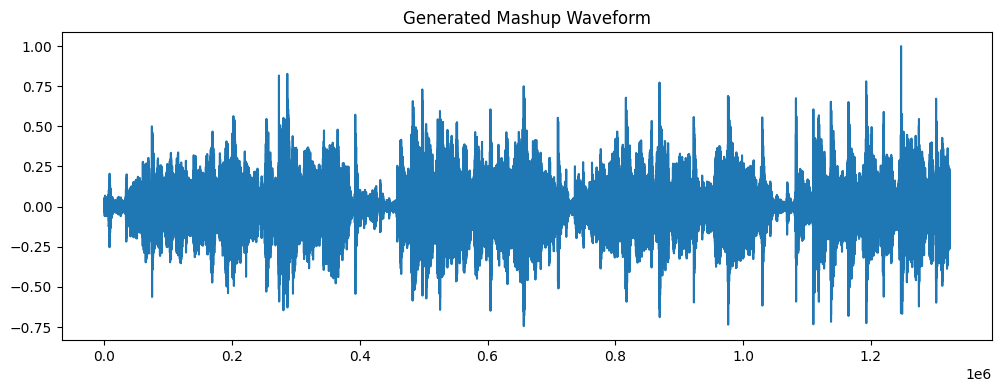

In [30]:
genre = random.choice(list(GENRE_PATH.iterdir()))
print("Selected genre:", genre.name)

audio = generate_mashup(genre)
print("Audio length:", len(audio))
print("Duration (sec):", len(audio)/TARGET_SR)
print("Amplitude range:", np.min(audio), np.max(audio))
plt.figure(figsize=(12,4))
plt.plot(audio)
plt.title("Generated Mashup Waveform")
plt.show()

from IPython.display import Audio
Audio(audio, rate=TARGET_SR)

Mel shape: (128, 2586)


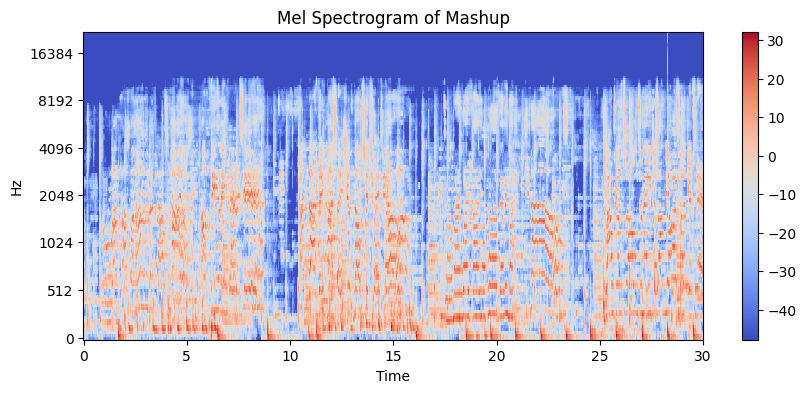

In [31]:
mel = mel_spectrogram(audio)
print("Mel shape:", mel.shape)
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel,
    sr=TARGET_SR,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Mel Spectrogram of Mashup")
plt.show()